# Graph Attention Network (GAT)

In [59]:
#| output: false

import sys
from pathlib import Path

# set to root for src load
root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

sys.path.insert(0, str(root))
print("Project root:", root)

Project root: d:\CS273P_MachineLearning_Final_Project


In [60]:
import json
import joblib
import libpysal
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap, Normalize
from matplotlib.patches import Patch
import seaborn as sns
from IPython.display import display
from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn

from src.gat import (
    GAT,
    build_graph_from_weights,
    build_optimizer,
    count_parameters,
    evaluate_regression,
    evaluate_regression_per_target,
    extract_attention_weights,
    get_device,
    predict_gat,
    set_seed,
    train_gat,
)

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.title_fontsize": 9,
    "legend.frameon": True,
    "legend.borderpad": 0.3
})

SEED = 254
set_seed(SEED)

## Model Motivation

The Graph Attention Network (GAT) extends the spatial graph-based approach by introducing learnable attention mechanisms that enable the model to distinguish which neighboring counties exert stronger influence on their neighboring counterparts. Unlike the GCN baseline that uses fixed normalized weights based on graph topology, GAT computes attention coefficients dynamically based on the learned representations of connected nodes.

GAT approaches are appropriate for disaster assistance prediction because geographic proximity does not always imply uniform influence; in other words, a county's disaster assistance outcomes may be strongly influenced by certain neighbors due to shared infrastructure, economic conditions, or disaster exposure patterns. By learning these attention weights from data, a GAT provides both improved predictive capability and interpretability through analysis of weighted spatial relationships.

The adaptive weighting mechanism addresses a specific limitation of GCNs; specifically, in GCNs, all neighbors contribute equally (after normalization) regardless of their relevance to the prediction task. However, GATs can learn to emphasize high-vulnerability corridors, disaster-prone regions, or economically connected counties while down-weighting less informative spatial relationships.

## Model Formulation

Let $\mathcal{G} = (\mathcal{V}, \mathcal{E})$ denote the spatial graph where $\mathcal{V}$ represents the set of $n$ counties and $\mathcal{E}$ represents the set of edges determined by Queen contiguity. Let $X \in \mathbb{R}^{n \times p}$ denote the feature matrix with $p = 15$ log-transformed SVI indicator variables, and let $y \in \mathbb{R}^{n}$ denote the target variable (total FEMA IHP assistance).

The GAT model learns a function

$$
f_{\theta}: \mathcal{G} \times \mathbb{R}^{n \times p} \rightarrow \mathbb{R}^{n}
$$

such that the predicted disaster assistance values are

$$
\hat{y} = f_{\theta}(\mathcal{G}, X)
$$

The key innovation of GAT is the attention mechanism that computes edge-specific attention coefficients. For each node $i$ and its neighbor $j \in \mathcal{N}(i)$, the attention coefficient is computed as:

$$
e_{ij} = \text{LeakyReLU}\left(\mathbf{a}^\top [W\mathbf{h}_i \| W\mathbf{h}_j]\right)
$$

where $W \in \mathbb{R}^{d' \times d}$ is a learnable linear transformation, $\mathbf{a} \in \mathbb{R}^{2d'}$ is a learnable attention vector, $\|$ denotes concatenation, and $\mathbf{h}_i, \mathbf{h}_j$ are the feature vectors for nodes $i$ and $j$.

These coefficients are normalized across neighbors using softmax:

$$
\alpha_{ij} = \frac{\exp(e_{ij})}{\sum_{k \in \mathcal{N}(i)} \exp(e_{ik})}
$$

The output features for node $i$ are computed as a weighted aggregation of neighbor features:

$$
\mathbf{h}'_i = \sigma\left(\sum_{j \in \mathcal{N}(i)} \alpha_{ij} W\mathbf{h}_j\right)
$$

where $\sigma(\cdot)$ is a nonlinear activation function (ELU in our implementation).

To stabilize learning and capture diverse spatial patterns, GAT employs multi-head attention. The output of $K$ attention heads is concatenated:

$$
\mathbf{h}'_i = \|_{k=1}^K \sigma\left(\sum_{j \in \mathcal{N}(i)} \alpha_{ij}^k W^k\mathbf{h}_j\right)
$$

For the final output layer, attention head outputs are averaged instead of concatenated to produce scalar predictions:

$$
\hat{y}_i = \frac{1}{K}\sum_{k=1}^K \sum_{j \in \mathcal{N}(i)} \alpha_{ij}^k W^k\mathbf{h}_j
$$

Model parameters are estimated by minimizing the mean squared error (MSE) between predicted and observed disaster assistance:

$$
\mathcal{L}(\theta) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

## Baseline Architecture

The baseline GAT uses a two-layer architecture with multi-head attention:

**Layer 1 (GAT):** $15 \rightarrow 64 \times 4$ heads  
**Layer 2 (GAT):** $256 \rightarrow 64 \times 1$ head  
**Output:** $64 \rightarrow 1$

The first layer uses 4 attention heads to capture diverse spatial patterns, producing a 256-dimensional representation (= 64 dimensions × 4 heads concatenated). The second layer uses a single attention head to consolidate information before the final linear regression layer. Dropout (0.2) is applied between layers for regularization, and LeakyReLU with slope -0.2 is used in the attention mechanism.

## Ablation Plan

An ablation study is conducted to identify which architectural components contribute most to predictive performance. Model selection and hyperparameter tuning are performed using the validation split only, with the held-out test split reserved for final evaluation:

1. **Attention Mechanism:** Comparing single-head (K=1), baseline multi-head (K=4), and many-head (K=8) configurations to assess whether learning heterogeneous spatial relationships improves prediction accuracy.

2. **Model Capacity:** Testing hidden dimensions of 32, 64 (baseline), and 128 units to determine whether the model has sufficient capacity to capture complex spatial patterns without overfitting.

3. **Regularization:** Varying dropout rates (0.0, 0.2, 0.5) to examine the importance of regularization for generalization in the prediction task.

Models are compared using RMSE and $R^2$ on the validation set, with metrics reported in scaled space to enable direct comparison with the MLP and GCN baselines. After identifying the best configuration, the final model is evaluated once on the test set to provide an unbiased estimate of generalization performance. These experiments establish whether the attention mechanism provides meaningful improvements over fixed aggregation schemes and identify the optimal GAT configuration for disaster assistance prediction.

## Data Loading and Preprocessing

We perform all data preprocessing from raw sources, including:
1. Loading CDC SVI county-level indicators
2. Loading and aggregating FEMA IHP disaster assistance data (2018-2020)
3. Loading county boundary geometries
4. Merging datasets and creating feature matrix
5. Applying log transformations to skewed features
6. Creating the target variable (total_ihp)

In [61]:
#| output: false

raw_dir = Path("../data/raw/")

# Load raw SVI data
print("Loading SVI data...")
svi = pd.read_csv(raw_dir / "SVI_2018_US_county.csv")
svi["FIPS"] = svi["FIPS"].astype(str).str.zfill(5)
print(f"SVI counties: {len(svi)}")

# Load and aggregate FEMA disaster assistance data
print("\nLoading FEMA data...")
fema = pd.read_csv(raw_dir / "fema_ihp_2018_2020_raw.csv")
fema = fema.drop(columns=["declarationDate", "disaster_count"], errors="ignore")
fema["ihpAmount"] = pd.to_numeric(fema["ihpAmount"], errors="coerce").fillna(0)
fema["fips"] = pd.to_numeric(fema["fips"], errors="coerce")
fema = fema.dropna(subset=["fips"]).copy()
fema["fips"] = fema["fips"].astype(int).astype(str).str.zfill(5)

# Aggregate FEMA assistance by county
fema_county = (
    fema.groupby("fips", as_index=False)
    .agg(total_ihp=("ihpAmount", "sum"))
)
print(f"FEMA counties: {len(fema_county)}")

# Load county geometries
print("\nLoading county geometries...")
counties = gpd.read_file(raw_dir / "tl_2018_us_county" / "tl_2018_us_county.shp")
counties["FIPS"] = (
    counties["STATEFP"].astype(str) + counties["COUNTYFP"].astype(str)
).str.zfill(5)
counties_subset = counties[["FIPS", "geometry"]]
print(f"County geometries: {len(counties_subset)}")

# Merge SVI with FEMA data
print("\nMerging datasets...")
df = svi.merge(
    fema_county,
    left_on="FIPS",
    right_on="fips",
    how="left"
).drop(columns=["fips"])

# Fill counties with no FEMA assistance as zero
df["total_ihp"] = df["total_ihp"].fillna(0)

# Merge with geometry
geo_df = df.merge(
    counties_subset,
    on="FIPS",
    how="inner"
).sort_values("FIPS").reset_index(drop=True)

geo_df = gpd.GeoDataFrame(geo_df, geometry="geometry")
print(f"Final dataset size: {len(geo_df)}")

# Define EP_* features to use
feature_cols_ep = [
    "EP_POV",
    "EP_UNEMP",
    "EP_PCI",
    "EP_NOHSDP",
    "EP_AGE65",
    "EP_AGE17",
    "EP_DISABL",
    "EP_SNGPNT",
    "EP_MINRTY",
    "EP_LIMENG",
    "EP_MUNIT",
    "EP_MOBILE",
    "EP_CROWD",
    "EP_NOVEH",
    "EP_GROUPQ"
]

# Extract features
X = geo_df[feature_cols_ep].copy()

# Apply log transformation to specific skewed features
log_vars = ["EP_LIMENG", "EP_CROWD", "EP_GROUPQ", "EP_MOBILE", "EP_NOVEH", "EP_MUNIT"]
X_log = X.copy()
for col in log_vars:
    X_log[f"{col}_LOG"] = np.log1p(X_log[col])
X_log = X_log.drop(columns=log_vars)
X_log = X_log.reindex(sorted(X_log.columns), axis=1)

# Extract target
y = geo_df[["total_ihp"]].copy()

print(f"\nPreprocessing complete:")
print(f"Total samples: {len(X_log)}")
print(f"Feature dimensionality: {X_log.shape[1]}")
print(f"Features: {list(X_log.columns)}")
print(f"Target: {list(y.columns)}")
print(f"Counties with assistance: {(y['total_ihp'] > 0).sum()} ({(y['total_ihp'] > 0).mean()*100:.1f}%)")
print(f"Total assistance: ${y['total_ihp'].sum():,.0f}")

Loading SVI data...
SVI counties: 3142

Loading FEMA data...
FEMA counties: 3127

Loading county geometries...
County geometries: 3233

Merging datasets...
Final dataset size: 3142

Preprocessing complete:
Total samples: 3142
Feature dimensionality: 15
Features: ['EP_AGE17', 'EP_AGE65', 'EP_CROWD_LOG', 'EP_DISABL', 'EP_GROUPQ_LOG', 'EP_LIMENG_LOG', 'EP_MINRTY', 'EP_MOBILE_LOG', 'EP_MUNIT_LOG', 'EP_NOHSDP', 'EP_NOVEH_LOG', 'EP_PCI', 'EP_POV', 'EP_SNGPNT', 'EP_UNEMP']
Target: ['total_ihp']
Counties with assistance: 3035 (96.6%)
Total assistance: $4,151,067,738


## Train-Validation-Test Split

We create stratified splits for training (60%), validation (20%), and test (20%) sets. The target variable (total_ihp) is highly skewed with many zero values, so we use stratification based on whether counties received any assistance to ensure balanced representation of zero and non-zero assistance amounts across splits.

In [62]:
#| output: false

from sklearn.model_selection import train_test_split

# Binary indicator for stratification
y_binary = (y.values.ravel() > 0).astype(int)

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test, idx_temp, idx_test = train_test_split(
    X_log.values,
    y.values,
    np.arange(len(X_log)),
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

# Second split: 75% of temp = train (60% of total), 25% of temp = val (20% of total)
y_temp_binary = (y_temp.ravel() > 0).astype(int)
X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X_temp,
    y_temp,
    idx_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp_binary
)

print(f"Training samples: {len(X_train)} ({len(X_train)/len(X_log)*100:.1f}%)")
print(f"Validation samples: {len(X_val)} ({len(X_val)/len(X_log)*100:.1f}%)")
print(f"Test samples: {len(X_test)} ({len(X_test)/len(X_log)*100:.1f}%)")
print(f"\nTarget distribution (% with assistance > 0):")
print(f"Train: {(y_train.ravel() > 0).mean()*100:.1f}%")
print(f"Val:   {(y_val.ravel() > 0).mean()*100:.1f}%")
print(f"Test:  {(y_test.ravel() > 0).mean()*100:.1f}%")

Training samples: 1884 (60.0%)
Validation samples: 629 (20.0%)
Test samples: 629 (20.0%)

Target distribution (% with assistance > 0):
Train: 96.6%
Val:   96.5%
Test:  96.7%


## Feature and Target Scaling

We standardize both features and targets using StandardScaler. The target (total_ihp) has a very large range and skewed distribution, so scaling helps with gradient stability during training. We fit scalers on the training set and transform all splits to prevent data leakage.

In [63]:
#| output: false

from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

print(f"Feature scale stats (train):")
print(f"Mean: {X_train_scaled.mean(axis=0).mean():.4f}")
print(f"Std:  {X_train_scaled.std(axis=0).mean():.4f}")

print(f"\nTarget scale stats (train):")
print(f"Mean: {y_train_scaled.mean():.4f}")
print(f"Std:  {y_train_scaled.std():.4f}")

Feature scale stats (train):
Mean: 0.0000
Std:  1.0000

Target scale stats (train):
Mean: -0.0000
Std:  1.0000


## Graph Construction Using Queen Contiguity

The spatial adjacency graph is constructed using Queen contiguity, where two counties are connected if they share a border or vertex. We focus on CONUS counties to avoid artificial long-distance edges and ensure the graph structure reflects meaningful geographic relationships.

In [64]:
#| output: false

# Filter to CONUS only
conus_mask = ~geo_df["FIPS"].str.startswith(("02", "15", "60", "66", "69", "72", "78"))
conus_indices = np.where(conus_mask.values)[0]

conus = geo_df[conus_mask].copy().reset_index(drop=True)

print(f"Total counties: {len(geo_df)}")
print(f"CONUS counties: {len(conus)}")

# Build Queen contiguity weights
w_queen = libpysal.weights.Queen.from_dataframe(conus, use_index=True)

print(f"Max neighbors: {max(w_queen.cardinalities.values())}")
print(f"Nodes: {w_queen.n}")
print(f"Min neighbors: {min(w_queen.cardinalities.values())}")
print(f"Edges: {int(w_queen.s0 / 2)}")
print(f"Average neighbors: {w_queen.mean_neighbors:.2f}")

Total counties: 3142
CONUS counties: 3108
Max neighbors: 14
Nodes: 3108
Min neighbors: 1
Edges: 9231
Average neighbors: 5.94


## Map Train-Val-Test Splits to CONUS Indices

Since the train-validation-test splits were created from the full dataset (including OCONUS), we need to map these indices to the CONUS-only subset. We extract the CONUS data for each split and create new index mappings for graph construction.

In [65]:
#| output: false

# Map original indices to CONUS subset
original_to_conus = {orig_idx: conus_idx for conus_idx, orig_idx in enumerate(conus_indices)}

# Filter train/val/test to CONUS only
train_conus_mask = np.isin(idx_train, conus_indices)
val_conus_mask = np.isin(idx_val, conus_indices)
test_conus_mask = np.isin(idx_test, conus_indices)

# Get CONUS-relative indices
train_conus_idx = np.array([original_to_conus[i] for i in idx_train[train_conus_mask]])
val_conus_idx = np.array([original_to_conus[i] for i in idx_val[val_conus_mask]])
test_conus_idx = np.array([original_to_conus[i] for i in idx_test[test_conus_mask]])

# Extract CONUS data
X_train_conus = X_train_scaled[train_conus_mask]
X_val_conus = X_val_scaled[val_conus_mask]
X_test_conus = X_test_scaled[test_conus_mask]

y_train_conus = y_train_scaled[train_conus_mask]
y_val_conus = y_val_scaled[val_conus_mask]
y_test_conus = y_test_scaled[test_conus_mask]

X_conus_full = scaler_X.transform(X_log.iloc[conus_indices].values)
y_conus_full = scaler_y.transform(y.iloc[conus_indices].values)

print(f"CONUS train samples: {len(train_conus_idx)}")
print(f"CONUS val samples: {len(val_conus_idx)}")
print(f"CONUS test samples: {len(test_conus_idx)}")
print(f"Total CONUS: {len(train_conus_idx) + len(val_conus_idx) + len(test_conus_idx)}")
print(f"Full CONUS dataset: {X_conus_full.shape[0]} samples")

CONUS train samples: 1865
CONUS val samples: 620
CONUS test samples: 623
Total CONUS: 3108
Full CONUS dataset: 3108 samples


## Build PyTorch Geometric Data Objects

We construct graph data objects for training, validation, and test splits. Each graph contains nodes from the respective split and their spatial connections based on the CONUS Queen contiguity structure.

In [66]:
#| output: false

train_data = build_graph_from_weights(
    w_queen, X_conus_full, y_conus_full, node_indices=train_conus_idx
)

val_data = build_graph_from_weights(
    w_queen, X_conus_full, y_conus_full, node_indices=val_conus_idx
)

test_data = build_graph_from_weights(
    w_queen, X_conus_full, y_conus_full, node_indices=test_conus_idx
)

full_data = build_graph_from_weights(
    w_queen, X_conus_full, y_conus_full
)

print(f"Train graph: {train_data.num_nodes} nodes, {train_data.num_edges} edges")
print(f"Val graph: {val_data.num_nodes} nodes, {val_data.num_edges} edges")
print(f"Test graph: {test_data.num_nodes} nodes, {test_data.num_edges} edges")
print(f"Full graph: {full_data.num_nodes} nodes, {full_data.num_edges} edges")

print(f"\nEdge index: {train_data.edge_index.shape}")
print(f"Node features: {train_data.x.shape}")
print(f"Node targets: {train_data.y.shape}")

Train graph: 1865 nodes, 6546 edges
Val graph: 620 nodes, 714 edges
Test graph: 623 nodes, 814 edges
Full graph: 3108 nodes, 18462 edges

Edge index: torch.Size([2, 6546])
Node features: torch.Size([1865, 15])
Node targets: torch.Size([1865, 1])


## Baseline GAT Configuration

The baseline GAT model configuration is summarized below. This architecture uses multi-head attention in the first layer to capture diverse spatial patterns, followed by a single-head second layer to consolidate information before prediction.

In [67]:
#| output: false

input_dim = X_conus_full.shape[1]
output_dim = y_conus_full.shape[1]

print(f"Model input dimensions: {input_dim}")
print(f"Model output dimensions: {output_dim}")

gat_config = {
    "input_dim": input_dim,
    "hidden_dim": 64,
    "output_dim": output_dim,
    "num_heads": 4,
    "num_heads_out": 1,
    "dropout": 0.2,
    "negative_slope": 0.2,
}

model = GAT(**gat_config)

print(f"Total trainable parameters: {count_parameters(model):,}")
print(f"\n{model}")

Model input dimensions: 15
Model output dimensions: 1
Total trainable parameters: 21,249

GAT(
  (conv1): GATConv(15, 64, heads=4)
  (conv2): GATConv(256, 64, heads=1)
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
)


## Model Training

The GAT model is trained using the Adam optimizer with learning rate $1 \times 10^{-3}$ and L2 weight decay $1 \times 10^{-4}$ for regularization. Early stopping with patience of 50 epochs is applied based on validation loss to prevent overfitting. Training proceeds for a maximum of 500 epochs.

In [68]:
#| output: false

device = get_device()
print(f"Using device: {device}")

criterion = nn.MSELoss()
optimizer = build_optimizer(model, learning_rate=1e-3, weight_decay=1e-4)

model, history, best_epoch, best_val_loss = train_gat(
    model=model,
    train_data=train_data,
    val_data=val_data,
    criterion=criterion,
    optimizer=optimizer,
    max_epochs=500,
    patience=50,
    device=device,
)

print(f"Training complete:")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss (MSE): {best_val_loss:.6f}")
print(f"Best validation RMSE: {np.sqrt(best_val_loss):.6f}")

Using device: cpu
Training complete:
Best epoch: 200
Best validation loss (MSE): 2.073799
Best validation RMSE: 1.440069


## Training History

The training curves show convergence behavior and validation loss stabilization. Early stopping prevents overfitting while allowing the model to learn meaningful spatial attention patterns from the data.

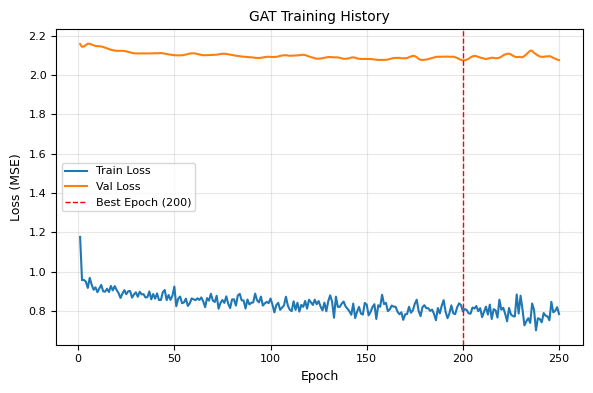

In [85]:
#| label: fig-gat-training-history
#| fig-cap: "Training and validation loss curves for the GAT model. The validation loss stabilizes after the initial epochs and early stopping is triggered at the optimal checkpoint, preventing overfitting while capturing spatial dependency patterns."

fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(history["epoch"], history["train_loss"], label="Train Loss", linewidth=1.5)
ax.plot(history["epoch"], history["val_loss"], label="Val Loss", linewidth=1.5)
ax.axvline(best_epoch, color="red", linestyle="--", linewidth=1, label=f"Best Epoch ({best_epoch})")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (MSE)")
ax.set_title("GAT Training History")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Test Set Evaluation

The trained GAT model is evaluated on the held-out test set. Performance is reported in scaled space (standardized log-transformed values) to enable direct comparison with the MLP and GCN baselines, with original dollar-scale metrics provided for interpretability.

In [86]:
#| output: false

# Get predictions on test set
y_pred_test_scaled = predict_gat(model, test_data, device=device)

# Compute metrics in scaled space (comparable to MLP baseline)
test_metrics_scaled = evaluate_regression(test_data.y.cpu().numpy(), y_pred_test_scaled)

print("Test Set Performance (Scaled Space):")
print(f"RMSE: {test_metrics_scaled['rmse']:.6f}")
print(f"R²:   {test_metrics_scaled['r2']:.6f}")

# Also compute original scale for interpretability
y_pred_test = scaler_y.inverse_transform(y_pred_test_scaled)
y_test_original = scaler_y.inverse_transform(test_data.y.cpu().numpy())
test_metrics_original = evaluate_regression(y_test_original, y_pred_test)

print(f"\nTest Set Performance (Original Dollar Scale):")
print(f"RMSE: ${test_metrics_original['rmse']:,.2f}")
print(f"R²:   {test_metrics_original['r2']:.6f}")

Test Set Performance (Scaled Space):
RMSE: 1.097484
R²:   0.084496

Test Set Performance (Original Dollar Scale):
RMSE: $5,215,095.38
R²:   0.084496


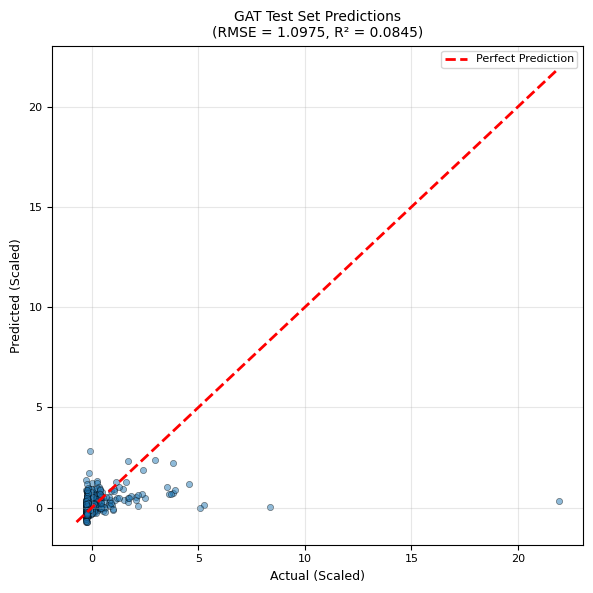

In [71]:
#| label: fig-gat-predictions-scatter
#| fig-cap: "Scatter plot of predicted vs actual FEMA disaster assistance in scaled space (standardized log-transformed values). Points near the diagonal line indicate accurate predictions. This visualization uses the same scale as the MLP baseline for direct comparison."

fig, ax = plt.subplots(figsize=(6, 6))

# Plot in scaled space (comparable to MLP)
y_test_scaled = test_data.y.cpu().numpy().ravel()
y_pred_scaled = y_pred_test_scaled.ravel()

ax.scatter(
    y_test_scaled,
    y_pred_scaled,
    alpha=0.5,
    s=20,
    edgecolors='k',
    linewidths=0.5
)

# Add diagonal line
min_val = min(y_test_scaled.min(), y_pred_scaled.min())
max_val = max(y_test_scaled.max(), y_pred_scaled.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax.set_xlabel('Actual (Scaled)')
ax.set_ylabel('Predicted (Scaled)')
ax.set_title(f'GAT Test Set Predictions\n(RMSE = {test_metrics_scaled["rmse"]:.4f}, R² = {test_metrics_scaled["r2"]:.4f})')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Ablation Study

To identify which architectural components contribute most to predictive performance, an ablation study is conducted testing seven configurations:

1. **Baseline GAT** - 64 hidden units, 4 attention heads, dropout 0.2 (reference configuration)
2. **Single Head** - 1 attention head instead of 4 (tests importance of multi-head attention)
3. **8 Heads** - 8 attention heads instead of 4 (tests benefits of additional attention capacity)
4. **Hidden=32** - 32 hidden units instead of 64 (reduced model capacity)
5. **Hidden=128** - 128 hidden units instead of 64 (increased model capacity)
6. **No Dropout** - Dropout set to 0.0 (no regularization)
7. **Dropout=0.5** - Dropout set to 0.5 (stronger regularization)

Each configuration is trained with the same optimization settings (Adam, learning rate $1 \times 10^{-3}$, weight decay $1 \times 10^{-4}$, early stopping patience 50 epochs). Performance is evaluated on the test set using RMSE and $R^2$ in scaled space to enable comparison across all experiments.

In [72]:
#| output: false

# Define ablation configurations
ablation_configs = {
    "Baseline GAT": {
        "input_dim": input_dim,
        "hidden_dim": 64,
        "output_dim": output_dim,
        "num_heads": 4,
        "num_heads_out": 1,
        "dropout": 0.2,
        "negative_slope": 0.2,
    },
    "Single Head": {
        "input_dim": input_dim,
        "hidden_dim": 64,
        "output_dim": output_dim,
        "num_heads": 1,
        "num_heads_out": 1,
        "dropout": 0.2,
        "negative_slope": 0.2,
    },
    "8 Heads": {
        "input_dim": input_dim,
        "hidden_dim": 64,
        "output_dim": output_dim,
        "num_heads": 8,
        "num_heads_out": 1,
        "dropout": 0.2,
        "negative_slope": 0.2,
    },
    "Hidden=32": {
        "input_dim": input_dim,
        "hidden_dim": 32,
        "output_dim": output_dim,
        "num_heads": 4,
        "num_heads_out": 1,
        "dropout": 0.2,
        "negative_slope": 0.2,
    },
    "Hidden=128": {
        "input_dim": input_dim,
        "hidden_dim": 128,
        "output_dim": output_dim,
        "num_heads": 4,
        "num_heads_out": 1,
        "dropout": 0.2,
        "negative_slope": 0.2,
    },
    "No Dropout": {
        "input_dim": input_dim,
        "hidden_dim": 64,
        "output_dim": output_dim,
        "num_heads": 4,
        "num_heads_out": 1,
        "dropout": 0.0,
        "negative_slope": 0.2,
    },
    "Dropout=0.5": {
        "input_dim": input_dim,
        "hidden_dim": 64,
        "output_dim": output_dim,
        "num_heads": 4,
        "num_heads_out": 1,
        "dropout": 0.5,
        "negative_slope": 0.2,
    },
}

# Train each configuration
ablation_results = []

for config_name, config in ablation_configs.items():
    print(f"\nTraining: {config_name}")
    
    # Create model
    ablation_model = GAT(**config)
    ablation_optimizer = build_optimizer(ablation_model, learning_rate=1e-3, weight_decay=1e-4)
    
    print(f"Parameters: {count_parameters(ablation_model):,}")
    
    # Train
    ablation_model, ablation_history, ablation_best_epoch, ablation_best_val_loss = train_gat(
        model=ablation_model,
        train_data=train_data,
        val_data=val_data,
        criterion=criterion,
        optimizer=ablation_optimizer,
        max_epochs=500,
        patience=50,
        device=device,
    )
    
    # Evaluate in scaled space (comparable to MLP)
    y_pred_scaled = predict_gat(ablation_model, test_data, device=device)
    y_test_scaled = test_data.y.cpu().numpy()
    
    metrics_scaled = evaluate_regression(y_test_scaled, y_pred_scaled)
    
    ablation_results.append({
        "Configuration": config_name,
        "Parameters": count_parameters(ablation_model),
        "Best Epoch": ablation_best_epoch,
        "Val Loss": ablation_best_val_loss,
        "Test RMSE": metrics_scaled["rmse"],
        "Test R²": metrics_scaled["r2"],
    })
    
    print(f"Best epoch: {ablation_best_epoch}")
    print(f"Test RMSE: {metrics_scaled['rmse']:.6f}")
    print(f"Test R²: {metrics_scaled['r2']:.6f}")

# Create results DataFrame
ablation_df = pd.DataFrame(ablation_results).sort_values("Test R²", ascending=False)


Training: Baseline GAT
Parameters: 21,249
Best epoch: 156
Test RMSE: 1.092770
Test R²: 0.092344

Training: Single Head
Parameters: 5,505
Best epoch: 233
Test RMSE: 1.086956
Test R²: 0.101975

Training: 8 Heads
Parameters: 42,241
Best epoch: 134
Test RMSE: 1.084422
Test R²: 0.106158

Training: Hidden=32
Parameters: 6,529
Best epoch: 278
Test RMSE: 1.094353
Test R²: 0.089713

Training: Hidden=128
Parameters: 75,265
Best epoch: 170
Test RMSE: 1.103243
Test R²: 0.074862

Training: No Dropout
Parameters: 21,249
Best epoch: 39
Test RMSE: 1.089569
Test R²: 0.097653

Training: Dropout=0.5
Parameters: 21,249
Best epoch: 391
Test RMSE: 1.091355
Test R²: 0.094692


In [73]:
#| label: tbl-ablation-results
#| tbl-cap: "Ablation study results comparing different GAT architectural configurations. Test RMSE is reported in scaled space for direct comparison with the MLP baseline. Models are sorted by test R² performance."

display(ablation_df.style.hide(axis="index").format({
    "Parameters": "{:,}",
    "Best Epoch": "{:.0f}",
    "Val Loss": "{:.6f}",
    "Test RMSE": "{:.6f}",
    "Test R²": "{:.6f}"
}))

Configuration,Parameters,Best Epoch,Val Loss,Test RMSE,Test R²
8 Heads,"42,241",134,2.051815,1.084422,0.106158
Single Head,"5,505",233,2.071029,1.086956,0.101975
No Dropout,"21,249",39,2.128666,1.089569,0.097653
Dropout=0.5,"21,249",391,2.072981,1.091355,0.094692
Baseline GAT,"21,249",156,2.065998,1.092770,0.092344
Hidden=32,"6,529",278,2.044703,1.094353,0.089713
Hidden=128,"75,265",170,2.062747,1.103243,0.074862


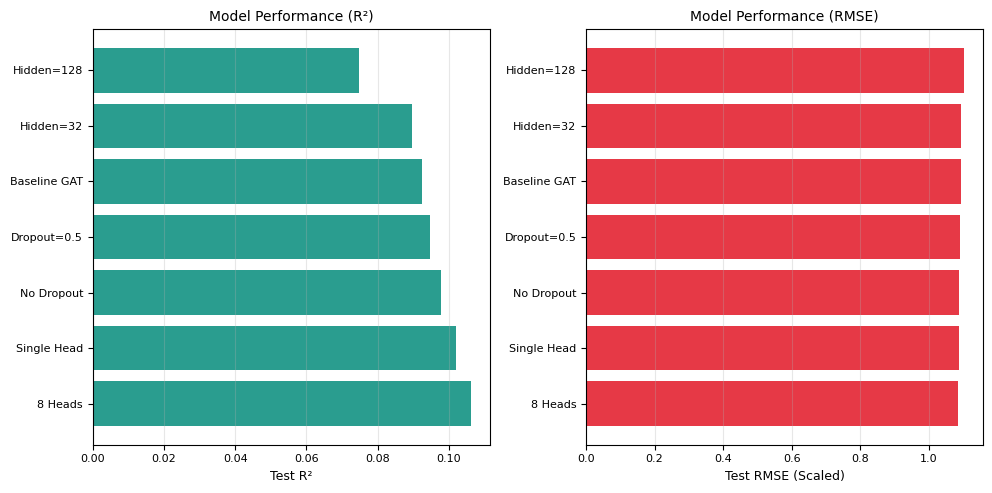

In [81]:
#| label: fig-ablation-comparison
#| fig-cap: "Visual comparison of ablation study results. The left panel shows test R² scores for different architectural configurations, while the right panel shows corresponding RMSE values in scaled space. Higher R² and lower RMSE indicate better performance."

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# R² comparison
axes[0].barh(ablation_df["Configuration"], ablation_df["Test R²"], color="#2a9d8f")
axes[0].set_xlabel("Test R²")
axes[0].set_title("Model Performance (R²)")
axes[0].grid(alpha=0.3, axis="x")

# RMSE comparison
axes[1].barh(ablation_df["Configuration"], ablation_df["Test RMSE"], color="#e63946")
axes[1].set_xlabel("Test RMSE (Scaled)")
axes[1].set_title("Model Performance (RMSE)")
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

## Attention Weight Analysis

One of the key advantages of GAT over GCN is interpretability through learned attention coefficients. The attention weights reveal which neighboring county relationships the model considers most influential for predicting disaster assistance outcomes.

By extracting and analyzing attention coefficients from the first GAT layer, we can understand how vulnerability information propagates through geographic space and identify which spatial connections are critical for prediction. High attention weights indicate that the model relies heavily on those neighbor relationships, while low weights suggest minimal influence despite geographic proximity.

This analysis provides insights into the spatial structure of disaster assistance patterns and validates whether the learned attention mechanism captures meaningful geographic relationships.

In [75]:
#| output: false

edge_index, attention_weights = extract_attention_weights(
    model, full_data, layer="layer1", device=device
)

print(f"Number of edges: {edge_index.shape[1]}")
print(f"Attention shape: {attention_weights.shape}")
print(f"Attention heads: {attention_weights.shape[1] if attention_weights.ndim > 1 else 1}")

if attention_weights.ndim > 1:
    attention_avg = attention_weights.mean(axis=1)
else:
    attention_avg = attention_weights

print(f"\nAttention statistics:")
print(f"Mean:   {attention_avg.mean():.4f}")
print(f"Median: {np.median(attention_avg):.4f}")
print(f"Std:    {attention_avg.std():.4f}")
print(f"Min:    {attention_avg.min():.4f}")
print(f"Max:    {attention_avg.max():.4f}")

Number of edges: 21570
Attention shape: (21570, 4)
Attention heads: 4

Attention statistics:
Mean:   0.1441
Median: 0.1332
Std:    0.0544
Min:    0.0055
Max:    0.6724


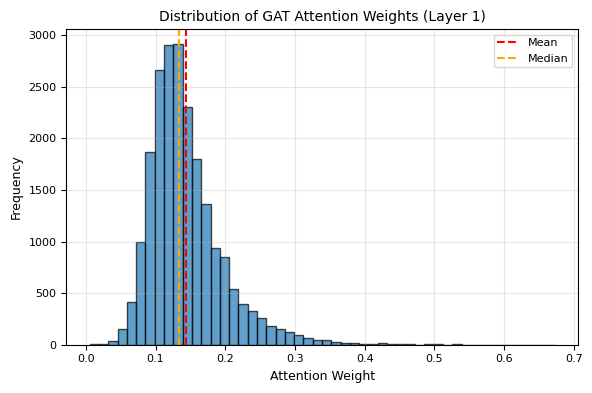

In [76]:
#| label: fig-gat-attention-distribution
#| fig-cap: "Distribution of learned attention weights across all county-to-county edges in the CONUS spatial graph. The attention coefficients are averaged across the four attention heads in the first GAT layer. The distribution shows how the model differentially weights spatial relationships, with some edges receiving substantially higher attention than others."

fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(attention_avg, bins=50, edgecolor="black", alpha=0.7)

ax.axvline(attention_avg.mean(), color="red", linestyle="--", linewidth=1.5, label="Mean")
ax.axvline(np.median(attention_avg), color="orange", linestyle="--", linewidth=1.5, label="Median")

ax.set_xlabel("Attention Weight")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of GAT Attention Weights (Layer 1)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Geographic Visualization of High-Attention Edges

To understand the spatial structure of learned attention, we visualize the geographic distribution of edges with the highest attention weights (≥95th percentile). This reveals which county-to-county relationships the GAT model prioritizes when predicting disaster assistance and how vulnerability information flows through the spatial network.

High-attention edges (≥95th percentile): 1079
Threshold value: 0.2466


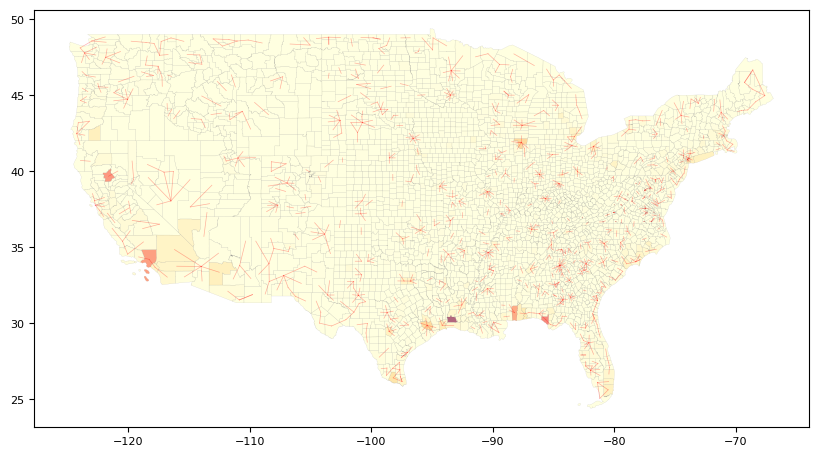

(np.float64(-127.7471505),
 np.float64(-63.987267499999994),
 np.float64(23.1469055),
 np.float64(50.6337605))

<Figure size 640x480 with 0 Axes>

In [77]:
#| label: fig-gat-high-attention-map
#| fig-cap: "Geographic visualization of high-attention edges in the CONUS county graph. Red lines indicate edges where the learned attention coefficient exceeds the 95th percentile, highlighting county-to-county relationships that the GAT model considers most influential for predicting FEMA disaster assistance. Counties are colored by their actual disaster assistance amounts for reference."

threshold = np.percentile(attention_avg, 95)
high_attention_mask = attention_avg >= threshold
high_attention_edges = edge_index[:, high_attention_mask]

print(f"High-attention edges (≥95th percentile): {high_attention_edges.shape[1]}")
print(f"Threshold value: {threshold:.4f}")

# Add disaster assistance data to conus for visualization
conus_with_data = conus.copy()
y_conus_original = scaler_y.inverse_transform(y_conus_full)
conus_with_data["total_ihp"] = y_conus_original.ravel()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

conus_with_data.plot(
    column="total_ihp",
    cmap="YlOrRd",
    linewidth=0.1,
    edgecolor="gray",
    alpha=0.6,
    legend=False,
    ax=ax,
)

# Draw high-attention edges
for i in range(high_attention_edges.shape[1]):
    src, dst = high_attention_edges[:, i]
    
    src_geom = conus.iloc[src].geometry.centroid
    dst_geom = conus.iloc[dst].geometry.centroid
    
    ax.plot(
        [src_geom.x, dst_geom.x],
        [src_geom.y, dst_geom.y],
        color="red",
        alpha=0.3,
        linewidth=0.5,

    )
    
plt.show()
plt.tight_layout()

ax.set_title("High-Attention Spatial Edges (≥95th Percentile)")
ax.axis("off")

## Mean Incoming Attention by County

In addition to examining individual high-attention edges, we analyze the mean attention weight received by each county from its neighbors. This aggregated metric identifies counties where spatial influence is particularly strong or weak according to the learned model.

In [78]:
#| output: false

incoming_attention = np.zeros(len(conus))

for i in range(edge_index.shape[1]):
    src, dst = edge_index[:, i]
    incoming_attention[dst] += attention_avg[i]

neighbor_counts = np.array([w_queen.cardinalities[i] for i in range(len(conus))])
mean_incoming_attention = incoming_attention / np.maximum(neighbor_counts, 1)
conus["mean_attention"] = mean_incoming_attention

print(f"Mean attention statistics:")
print(f"Mean:   {mean_incoming_attention.mean():.4f}")
print(f"Median: {np.median(mean_incoming_attention):.4f}")
print(f"Std:    {mean_incoming_attention.std():.4f}")

Mean attention statistics:
Mean:   0.1808
Median: 0.1667
Std:    0.0727


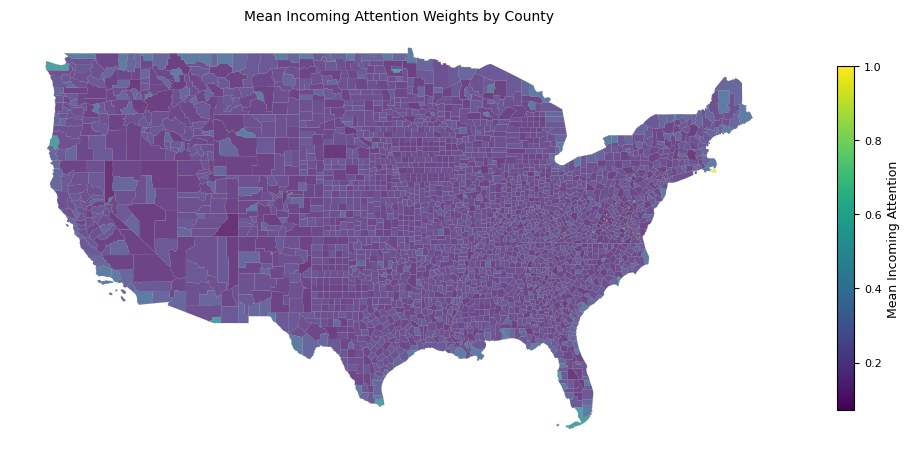

In [79]:
#| label: fig-gat-mean-attention-map
#| fig-cap: "Geographic distribution of mean incoming attention weights per county. Each county is colored by the average attention it receives from its neighbors. Darker shades indicate counties where the GAT model assigns higher importance to spatial influence from neighboring counties when predicting disaster assistance amounts."

fig, ax = plt.subplots(figsize=(10, 6))
conus_with_data["mean_attention"] = mean_incoming_attention

conus_with_data.plot(
    column="mean_attention",
    cmap="viridis",
    linewidth=0.1,
    edgecolor="gray",
    alpha=0.8,
    legend=True,
    legend_kwds={"label": "Mean Incoming Attention", "shrink": 0.6},
    ax=ax,
)

ax.set_title("Mean Incoming Attention Weights by County")
ax.axis("off")

plt.tight_layout()
plt.show()

## Attention Patterns and Disaster Risk

To assess whether the GAT model assigns differential attention to high-risk versus low-risk counties, we examine the relationship between predicted disaster assistance levels and mean incoming attention weights. This analysis tests whether counties with higher predicted vulnerability receive more attention from their neighbors, potentially indicating spatial diffusion of disaster impacts.

C:\Users\jlyon\AppData\Local\Temp\ipykernel_2168\874078171.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(


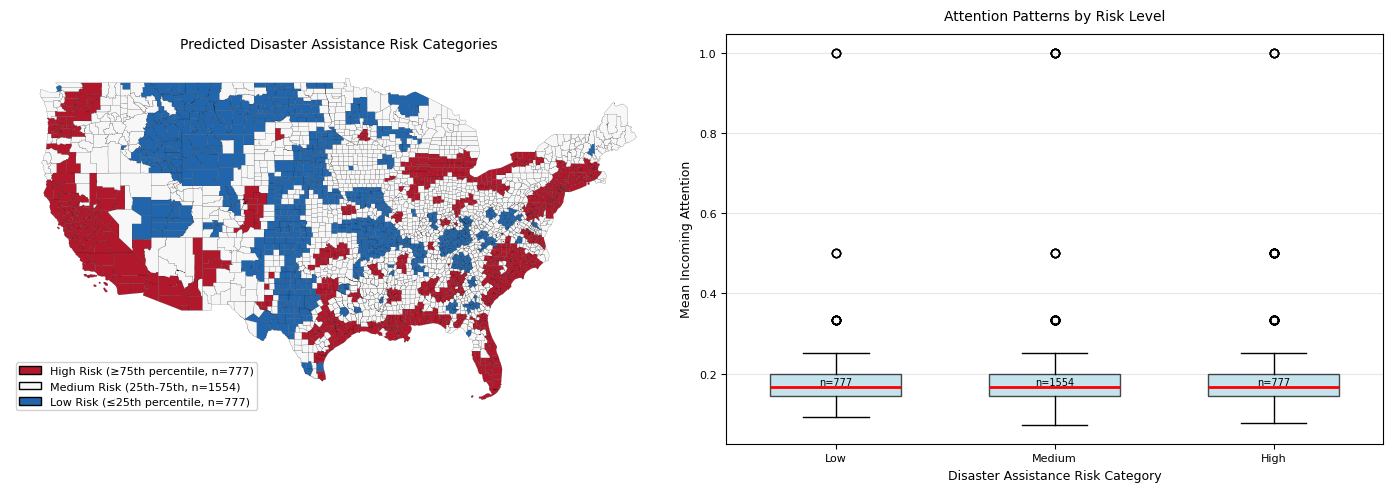


Mean Attention by Risk Category:
Low: 0.1778 ± 0.0664
Medium: 0.1760 ± 0.0667
High: 0.1933 ± 0.0873


In [80]:
#| label: fig-gat-high-risk-attention
#| fig-cap: "Relationship between disaster assistance needs and spatial attention patterns. Left: Counties classified by predicted disaster assistance risk level. Right: Distribution of mean incoming attention for high-risk vs. low-risk counties. This analysis examines whether the GAT assigns more attention to connections involving high-vulnerability counties."

# Generate predictions for the full CONUS dataset
y_pred_conus_scaled = predict_gat(model, full_data, device=device)
y_pred_conus = scaler_y.inverse_transform(y_pred_conus_scaled)

mean_pred_vulnerability = y_pred_conus.ravel()
conus_with_data["pred_total_ihp"] = mean_pred_vulnerability

high_risk_threshold = np.percentile(mean_pred_vulnerability, 75)
low_risk_threshold = np.percentile(mean_pred_vulnerability, 25)

conus_with_data["risk_category"] = "Medium"
conus_with_data.loc[mean_pred_vulnerability >= high_risk_threshold, "risk_category"] = "High"
conus_with_data.loc[mean_pred_vulnerability <= low_risk_threshold, "risk_category"] = "Low"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
risk_colors = {"Low": "#2166ac", "Medium": "#f7f7f7", "High": "#b2182b"}
cmap = ListedColormap([risk_colors[cat] for cat in ["Low", "Medium", "High"]])

conus_with_data["risk_cat_code"] = conus_with_data["risk_category"].map({"Low": 0, "Medium": 1, "High": 2})
conus_with_data.plot(
    column="risk_cat_code",
    cmap=cmap,
    linewidth=0.1,
    edgecolor="black",
    legend=False,
    ax=ax1,
)

legend_elements = [
    Patch(facecolor=risk_colors["High"], edgecolor="black", label=f"High Risk (≥75th percentile, n={sum(conus_with_data['risk_category']=='High')})"),
    Patch(facecolor=risk_colors["Medium"], edgecolor="black", label=f"Medium Risk (25th-75th, n={sum(conus_with_data['risk_category']=='Medium')})"),
    Patch(facecolor=risk_colors["Low"], edgecolor="black", label=f"Low Risk (≤25th percentile, n={sum(conus_with_data['risk_category']=='Low')})")
]
ax1.legend(handles=legend_elements, loc="lower left", fontsize=8, framealpha=0.9)
ax1.set_title("Predicted Disaster Assistance Risk Categories", fontsize=10, pad=10)
ax1.axis("off")

ax2 = axes[1]
attention_by_risk = [
    conus_with_data.loc[conus_with_data["risk_category"] == "Low", "mean_attention"].values,
    conus_with_data.loc[conus_with_data["risk_category"] == "Medium", "mean_attention"].values,
    conus_with_data.loc[conus_with_data["risk_category"] == "High", "mean_attention"].values
]

bp = ax2.boxplot(
    attention_by_risk, 
    labels=["Low", "Medium", "High"],
    patch_artist=True,
    medianprops=dict(color="red", linewidth=2),
    boxprops=dict(facecolor="lightblue", alpha=0.7),
    widths=0.6
)

ax2.set_xlabel("Disaster Assistance Risk Category", fontsize=9)
ax2.set_ylabel("Mean Incoming Attention", fontsize=9)
ax2.set_title("Attention Patterns by Risk Level", fontsize=10, pad=10)
ax2.grid(alpha=0.3, axis="y")

for i, cat in enumerate(["Low", "Medium", "High"]):
    n = len(attention_by_risk[i])
    median_val = np.median(attention_by_risk[i])
    ax2.text(i+1, median_val, f"n={n}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

print("\nMean Attention by Risk Category:")
for cat in ["Low", "Medium", "High"]:
    att_vals = conus_with_data.loc[conus_with_data["risk_category"] == cat, "mean_attention"]
    print(f"{cat}: {att_vals.mean():.4f} ± {att_vals.std():.4f}")